<a href="https://colab.research.google.com/github/Sivanunna/Logicmojo-AI-ML-Sept25--siva-/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/adult.csv')
df

Mounted at /content/drive


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [4]:
null_col = df.isnull().sum()/len(df)*100

In [5]:
null_col

,0
age,0.0
workclass,0.0
fnlwgt,0.0
education,0.0
educational-num,0.0
marital-status,0.0
occupation,0.0
relationship,0.0
race,0.0
gender,0.0


In [6]:
(df == "?").sum()/len(df)*100

,0
age,0.000000
workclass,5.730724
fnlwgt,0.000000
education,0.000000
educational-num,0.000000
marital-status,0.000000
occupation,5.751198
relationship,0.000000
race,0.000000
gender,0.000000


In [7]:
df['workclass'].value_counts()

,count
workclass,
Private,33906
Self-emp-not-inc,3862
Local-gov,3136
?,2799
State-gov,1981
Self-emp-inc,1695
Federal-gov,1432
Without-pay,21
Never-worked,10


In [8]:
mode = df['occupation'].mode()[0]
df['occupation'] = df['occupation'].replace('?', mode)

In [9]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [10]:
df.drop(['educational-num','fnlwgt'],axis=1,inplace=True)

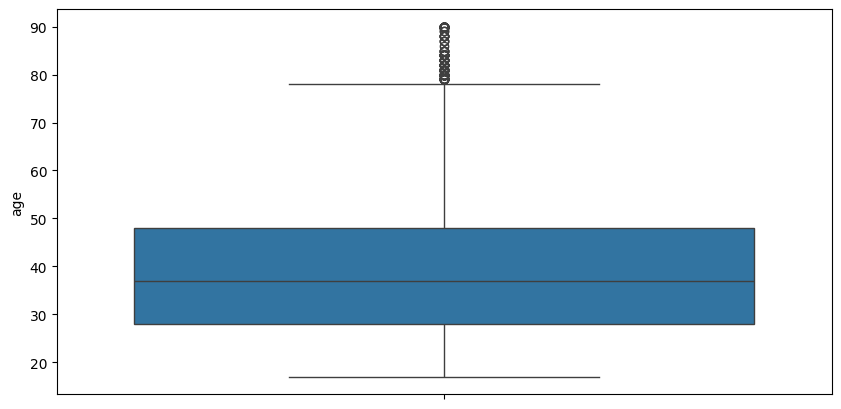

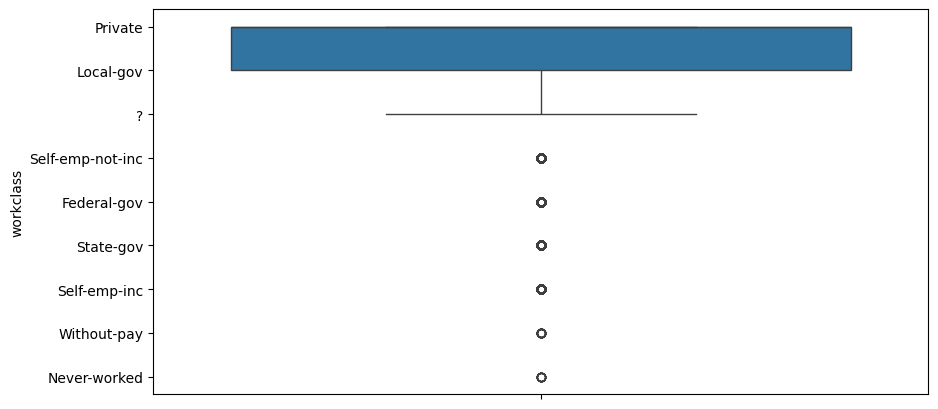

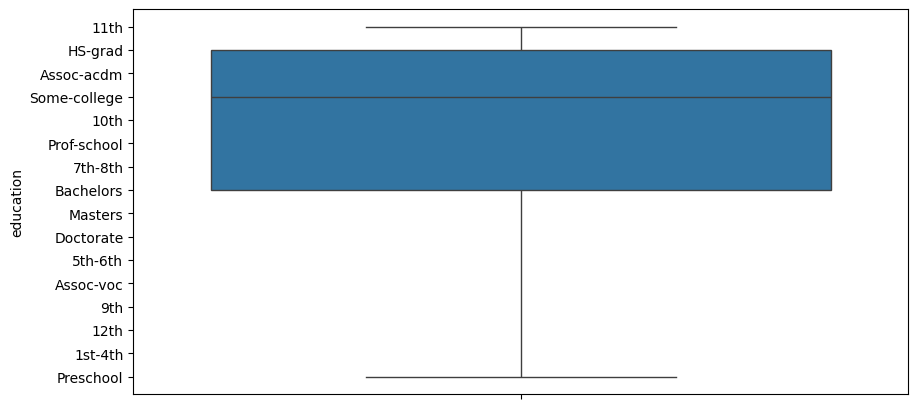

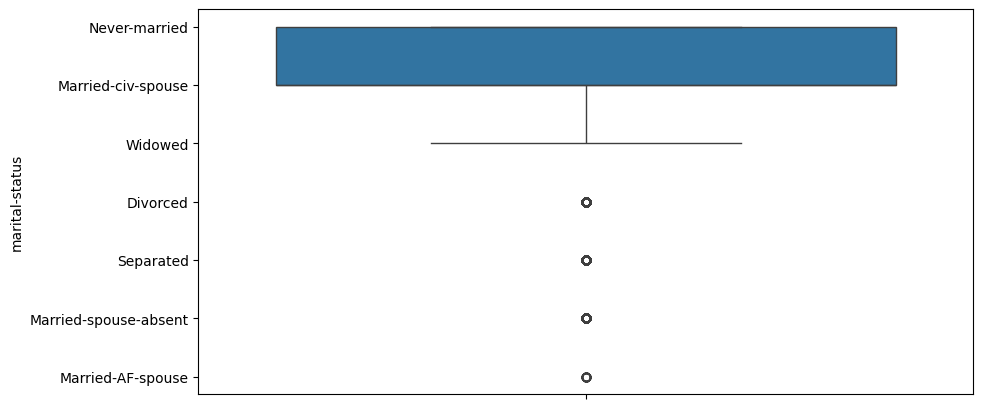

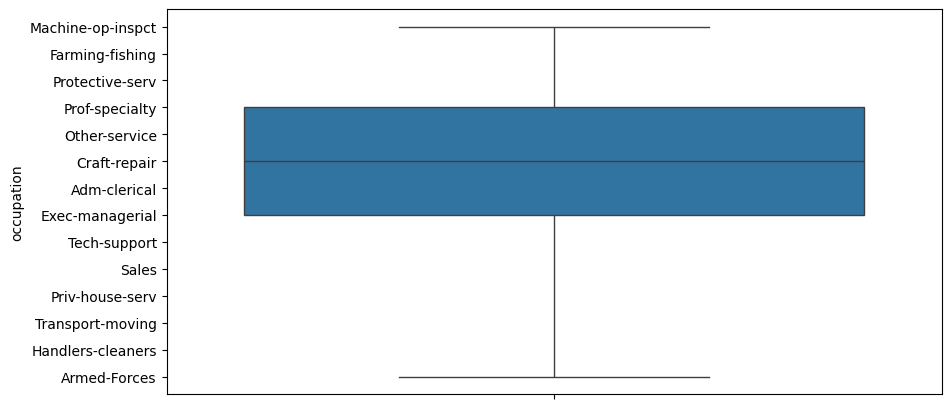

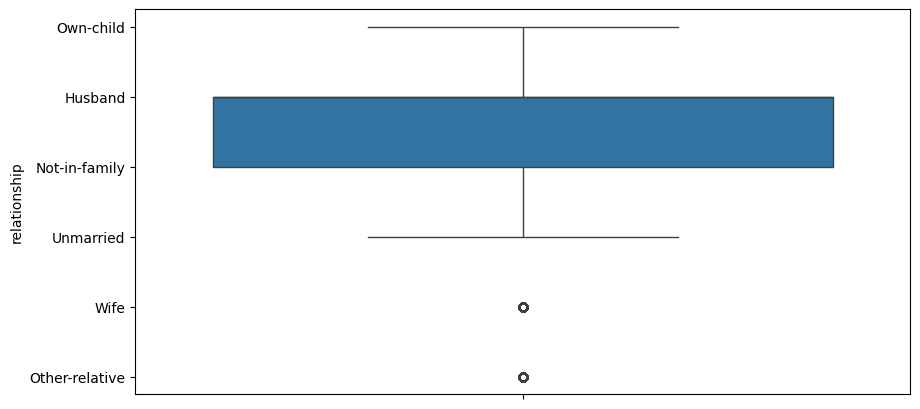

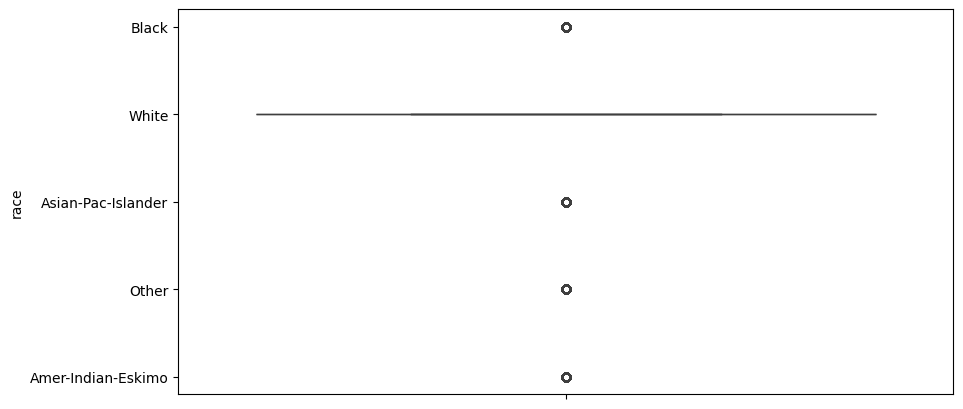

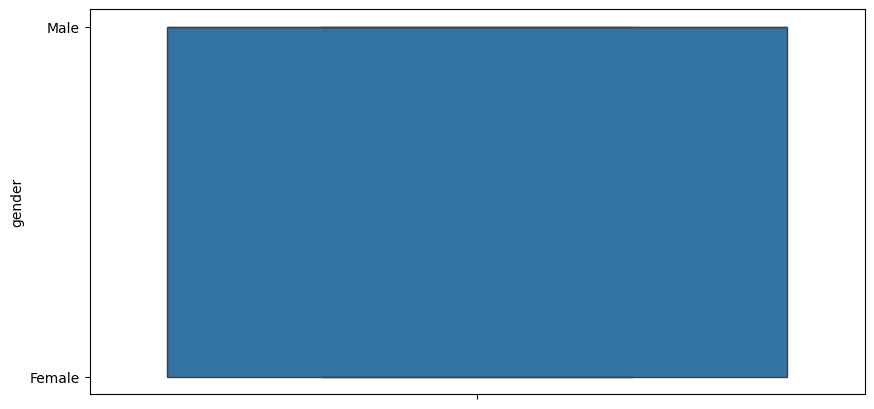

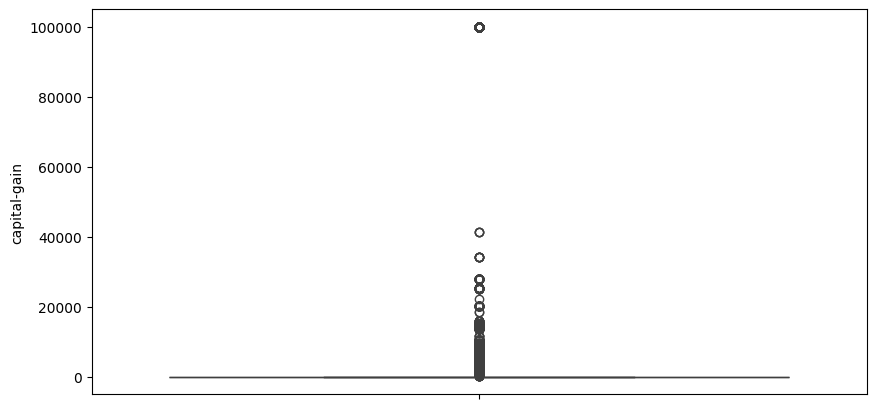

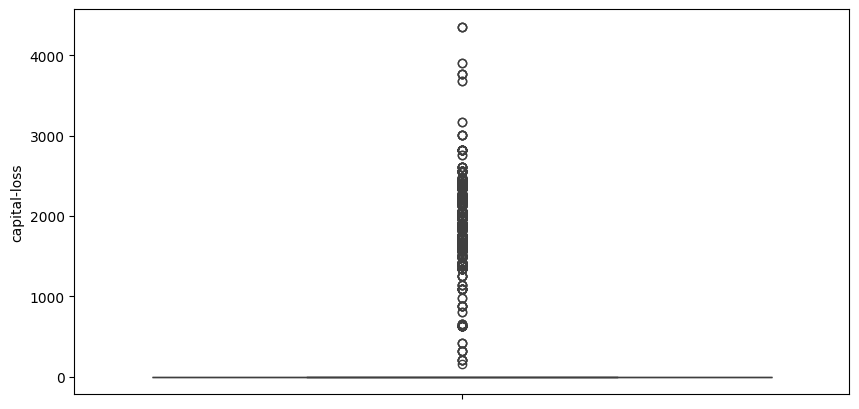

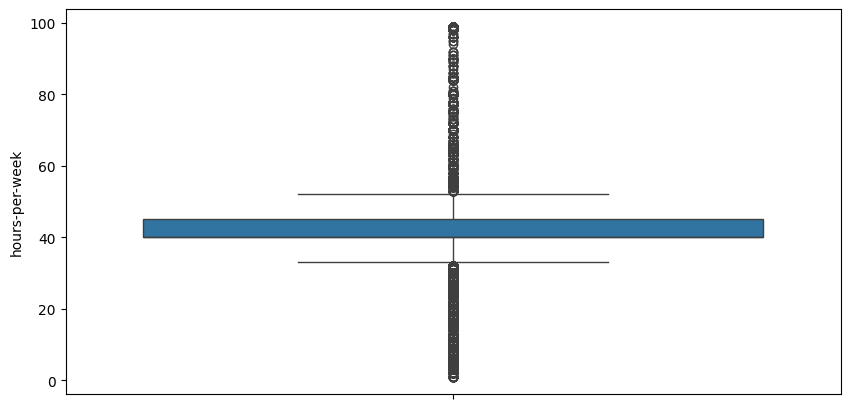

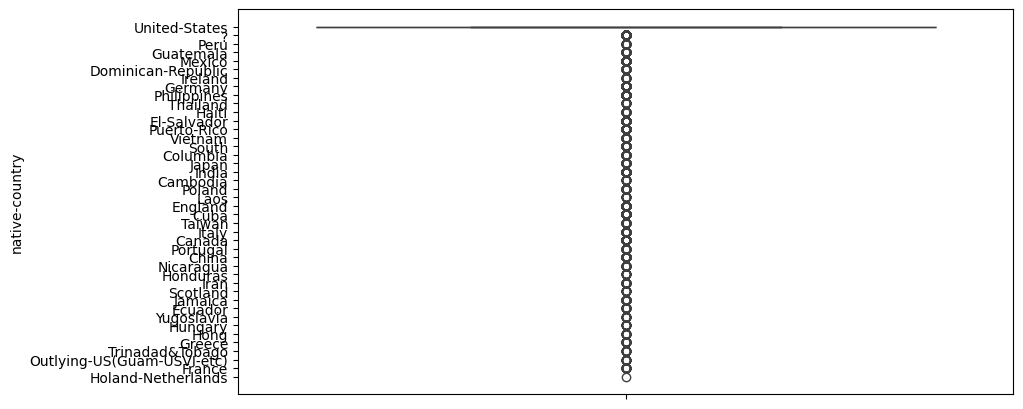

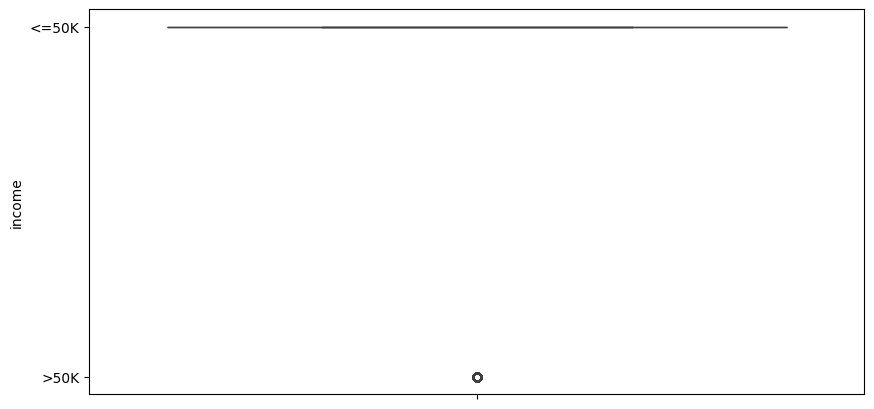

In [11]:
for col in df.columns:
  plt.figure(figsize=(10,5))
  sns.boxplot(df[col])
  plt.show()

In [12]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df['age'] = df['age'].clip(lower, upper)

In [13]:
Q1 = df['hours-per-week'].quantile(0.25)
Q3 = df['hours-per-week'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df['hours-per-week'] = df['hours-per-week'].clip(lower, upper)

In [14]:
df

,age,workclass,education,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,11th,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40.0,United-States,<=50K
1,38,Private,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50.0,United-States,<=50K
2,28,Local-gov,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40.0,United-States,>50K
3,44,Private,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40.0,United-States,>50K
4,18,?,Some-college,Never-married,Prof-specialty,Own-child,White,Female,0,0,32.5,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38.0,United-States,<=50K
48838,40,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40.0,United-States,>50K
48839,58,Private,HS-grad,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40.0,United-States,<=50K
48840,22,Private,HS-grad,Never-married,Adm-clerical,Own-child,White,Male,0,0,32.5,United-States,<=50K


In [15]:
df['native-country'] = df['native-country'].apply(lambda x : 'US' if x == 'United-States' else 'NON-US')

In [16]:
y = df['income']
x = df.drop('income',axis=1)

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [19]:
num_col = x.select_dtypes(include=np.number)
cat_col = x.select_dtypes(exclude=np.number)

In [20]:
num_col

,age,capital-gain,capital-loss,hours-per-week
0,25,0,0,40.0
1,38,0,0,50.0
2,28,0,0,40.0
3,44,7688,0,40.0
4,18,0,0,32.5
...,...,...,...,...
48837,27,0,0,38.0
48838,40,0,0,40.0
48839,58,0,0,40.0
48840,22,0,0,32.5


In [21]:
cat_col

,workclass,education,marital-status,occupation,relationship,race,gender,native-country
0,Private,11th,Never-married,Machine-op-inspct,Own-child,Black,Male,US
1,Private,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,US
2,Local-gov,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,White,Male,US
3,Private,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,US
4,?,Some-college,Never-married,Prof-specialty,Own-child,White,Female,US
...,...,...,...,...,...,...,...,...
48837,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Wife,White,Female,US
48838,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,US
48839,Private,HS-grad,Widowed,Adm-clerical,Unmarried,White,Female,US
48840,Private,HS-grad,Never-married,Adm-clerical,Own-child,White,Male,US


In [22]:
cat_col = pd.get_dummies(cat_col)

In [23]:
cat=cat_col.astype(int)

In [24]:
colu = num_col.columns

In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_col = scaler.fit_transform(num_col)

In [26]:
num_col = pd.DataFrame(num_col,columns=colu)

In [27]:
finaldf = pd.concat([num_col,cat],axis=1)

In [28]:
finaldf

,age,capital-gain,capital-loss,hours-per-week,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,gender_Female,gender_Male,native-country_NON-US,native-country_US
0,-0.999145,-0.144804,-0.217127,-0.192863,0,0,0,0,1,0,...,0,0,0,1,0,0,0,1,0,1
1,-0.045382,-0.144804,-0.217127,1.424021,0,0,0,0,1,0,...,0,0,0,0,0,1,0,1,0,1
2,-0.779046,-0.144804,-0.217127,-0.192863,0,0,1,0,0,0,...,0,0,0,0,0,1,0,1,0,1
3,0.394816,0.886874,-0.217127,-0.192863,0,0,0,0,1,0,...,0,0,0,1,0,0,0,1,0,1
4,-1.512710,-0.144804,-0.217127,-1.405526,1,0,0,0,0,0,...,0,0,0,0,0,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,-0.852412,-0.144804,-0.217127,-0.516240,0,0,0,0,1,0,...,1,0,0,0,0,1,1,0,0,1
48838,0.101351,-0.144804,-0.217127,-0.192863,0,0,0,0,1,0,...,0,0,0,0,0,1,0,1,0,1
48839,1.421946,-0.144804,-0.217127,-0.192863,0,0,0,0,1,0,...,0,0,0,0,0,1,1,0,0,1
48840,-1.219244,-0.144804,-0.217127,-1.405526,0,0,0,0,1,0,...,0,0,0,0,0,1,0,1,0,1


In [29]:
from sklearn.neighbors import KNeighborsClassifier  # Importing K Neighbors Classifier
from sklearn.metrics import confusion_matrix, classification_report

In [30]:
x_train_processed = finaldf.loc[x_train.index]
x_test_processed = finaldf.loc[x_test.index]

# Initialize KNN with k=5
kNN = KNeighborsClassifier(n_neighbors=15)

# Train the model
kNN.fit(x_train_processed, y_train)

# Make predictions on the test set
y_pred = kNN.predict(x_test_processed)

# Generate confusion matrix and classification report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[6884  595]
 [ 865 1425]]

Classification Report:
               precision    recall  f1-score   support

       <=50K       0.89      0.92      0.90      7479
        >50K       0.71      0.62      0.66      2290

    accuracy                           0.85      9769
   macro avg       0.80      0.77      0.78      9769
weighted avg       0.85      0.85      0.85      9769



In [31]:
train_accuracy = []  # List to store training accuracy scores for different values of K
test_accuracy = []
for i in range(1, 20):
    # Initialize KNN classifier with current value of K
    kn = KNeighborsClassifier(n_neighbors=i)
    kn.fit(x_train_processed, y_train)
    tr = kn.score(x_train_processed, y_train)  # Training accuracy
    te = kn.score(x_test_processed, y_test)

    train_accuracy.append(tr)
    test_accuracy.append(te)


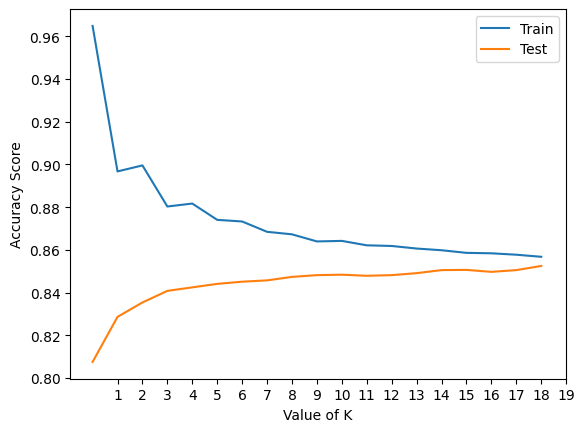

In [32]:
plt.plot(train_accuracy, label="Train")  # Plotting training accuracy scores
plt.plot(test_accuracy, label="Test")    # Plotting testing accuracy scores
plt.legend()                             # Displaying legend
plt.xlabel("Value of K")                  # Labeling x-axis
plt.ylabel("Accuracy Score")             # Labeling y-axis
plt.xticks(np.arange(1, 20))             # Setting x-axis ticks
plt.show()

In [33]:
from imblearn.combine import SMOTETomek

smt = SMOTETomek()
X_res, y_res = smt.fit_resample(x_train_processed, y_train)

knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_res, y_res)

KNeighborsClassifier(n_neighbors=15)

In [34]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_res, y_res)

LogisticRegression(max_iter=1000)

In [35]:
y_pred = lr.predict(x_test_processed)

In [36]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[6266 1213]
 [ 442 1848]]
              precision    recall  f1-score   support

       <=50K       0.93      0.84      0.88      7479
        >50K       0.60      0.81      0.69      2290

    accuracy                           0.83      9769
   macro avg       0.77      0.82      0.79      9769
weighted avg       0.86      0.83      0.84      9769



In [37]:
lr1 = LogisticRegression(class_weight='balanced', max_iter=1000)
lr1.fit(x_train_processed, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [38]:
ypredd = lr1.predict(x_test_processed)

In [39]:
print(classification_report(y_test, ypredd))

              precision    recall  f1-score   support

       <=50K       0.95      0.80      0.87      7479
        >50K       0.57      0.85      0.68      2290

    accuracy                           0.82      9769
   macro avg       0.76      0.83      0.78      9769
weighted avg       0.86      0.82      0.83      9769

